# Task 3 — Sound Data Collection & Processing
### Formative 2: Multimodal Data Preprocessing

> **Recording naming:** one folder per member under `audio/`, with files named `phrase1` / `phrase2` and any of these extensions: `.wav`, `.mp3`, `.flac`, `.m4a`, or `.mp4`.
> ```
> audio/
>   <member_name>/
>     phrase1.wav   ("Yes, approve")   — or .mp3 / .flac / .m4a / .mp4
>     phrase2.wav   ("Confirm transaction")
> ```
> The loader auto-discovers whatever member folders and supported extensions are present — no code changes needed when swapping recordings.

This notebook covers:
1. Loading and visualizing each member's recordings (waveform + spectrogram)
2. Augmentations (pitch shift, time stretch, background noise)
3. Feature extraction (MFCCs, spectral roll-off, energy) into `audio_features.csv`


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

AUDIO_DIR = 'audio'
PHRASES = ['phrase1', 'phrase2']  # phrase1 = "Yes, approve", phrase2 = "Confirm transaction"
SR = 22050
AUDIO_EXTS = ('wav', 'mp3', 'flac', 'm4a', 'mp4')

def discover_members(audio_dir=AUDIO_DIR):
    '''Finds every member subfolder and which phrase recordings exist for them.'''
    members = {}
    for member in sorted(os.listdir(audio_dir)):
        member_path = os.path.join(audio_dir, member)
        if not os.path.isdir(member_path):
            continue
        found = {}
        for phrase in PHRASES:
            for ext in AUDIO_EXTS:
                candidate = os.path.join(member_path, f'{phrase}.{ext}')
                if os.path.exists(candidate):
                    found[phrase] = candidate
                    break
        if found:
            members[member] = found
    return members

members = discover_members()
for m, files in members.items():
    print(m, '->', list(files.keys()))


amaliza -> ['phrase1', 'phrase2']
emmanuel -> ['phrase1', 'phrase2']
musana -> ['phrase1', 'phrase2']
vestine -> ['phrase1', 'phrase2']


## 1. Load & Visualize: Waveform + Spectrogram

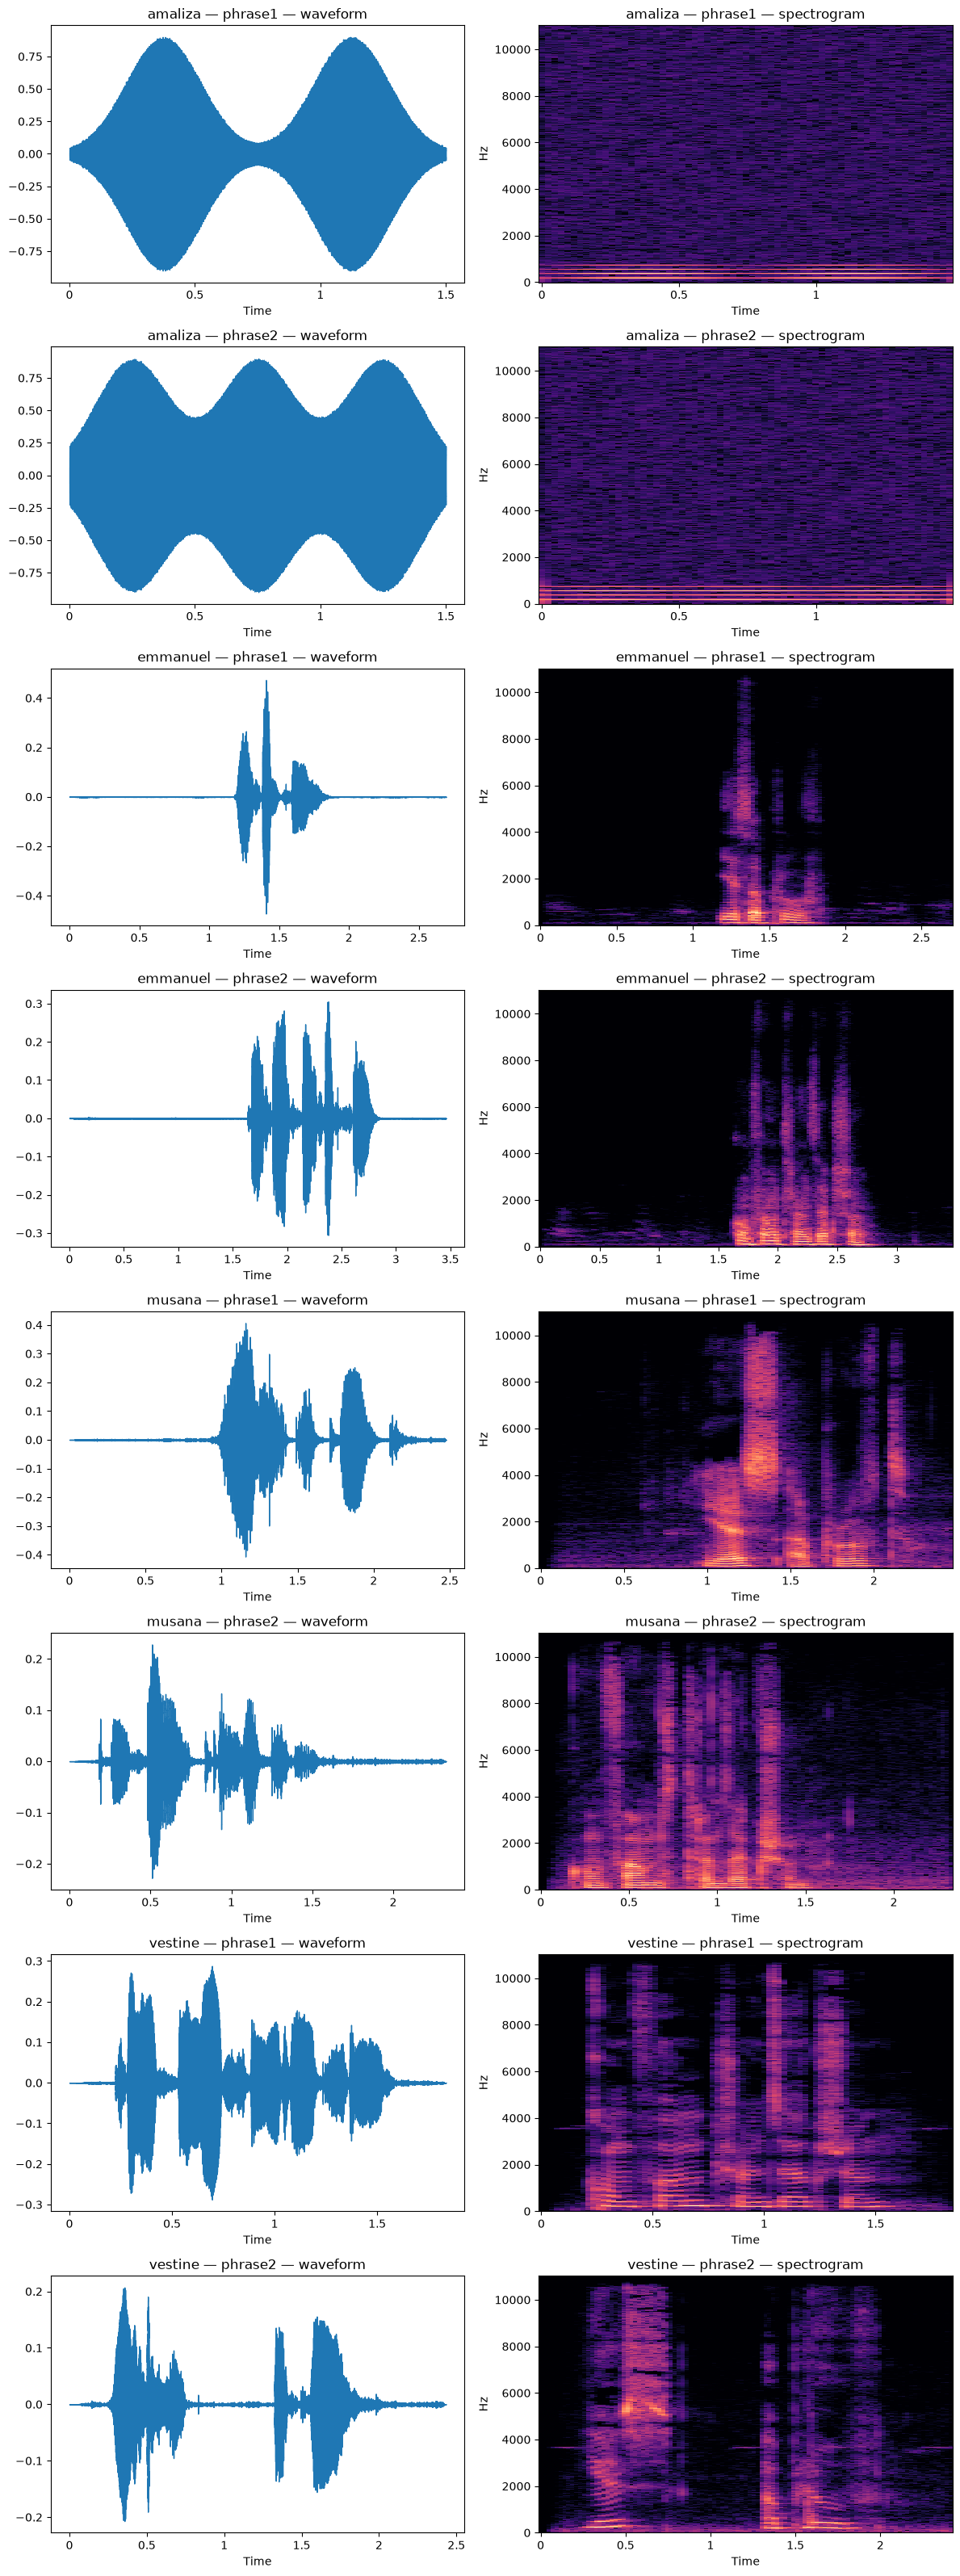

In [2]:
def load_audio(path, sr=SR):
    y, sr = librosa.load(path, sr=sr, mono=True)
    return y, sr

n_members = len(members)
fig, axes = plt.subplots(n_members * len(PHRASES), 2, figsize=(12, 4 * n_members * len(PHRASES)), squeeze=False)

row = 0
for member, files in members.items():
    for phrase in PHRASES:
        if phrase not in files:
            row += 1
            continue
        y, sr = load_audio(files[phrase])

        librosa.display.waveshow(y, sr=sr, ax=axes[row][0])
        axes[row][0].set_title(f'{member} — {phrase} — waveform')

        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[row][1])
        axes[row][1].set_title(f'{member} — {phrase} — spectrogram')
        row += 1

plt.tight_layout()
plt.savefig('audio_waveform_spectrogram.png')
plt.show()


## 2. Augmentations

At least two augmentations per sample, as required: **pitch shift**, **time stretch**, and **added background noise**. Each is applied independently to every original recording, and every augmented version gets its own row of extracted features later on — capturing how the same phrase sounds with vocal-pitch variation, pacing variation, and a noisy environment.


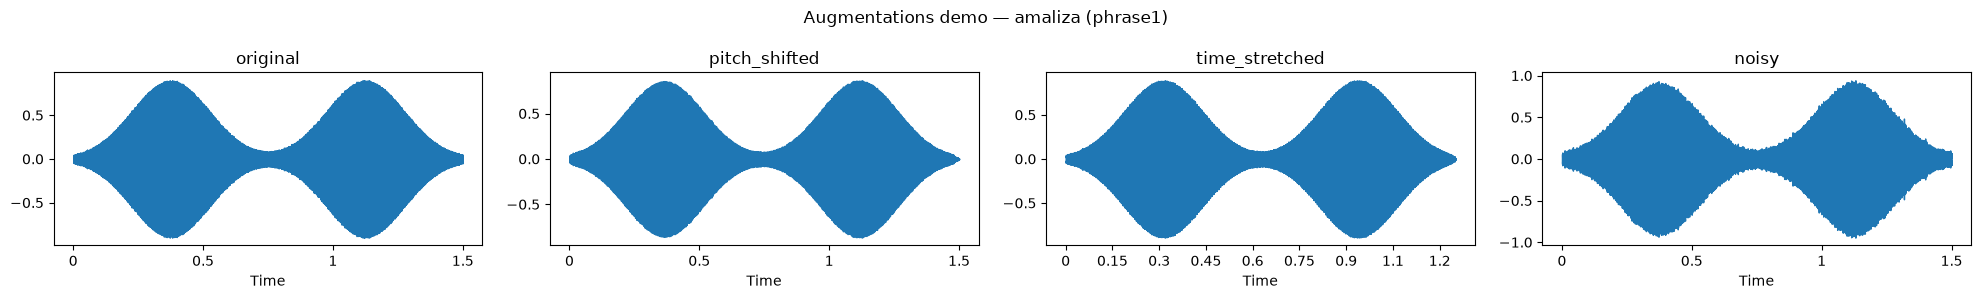

In [3]:
def augment_pitch_shift(y, sr, n_steps=3):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def augment_time_stretch(y, sr, rate=1.2):
    return librosa.effects.time_stretch(y, rate=rate)

def augment_add_noise(y, sr, noise_level=0.02):
    noise = np.random.randn(len(y))
    return y + noise_level * noise

AUGMENTATIONS = {
    'original': lambda y, sr: y,
    'pitch_shifted': augment_pitch_shift,
    'time_stretched': augment_time_stretch,
    'noisy': augment_add_noise,
}

# Show every augmentation's waveform for one member/phrase as a sanity check
demo_member = next(iter(members))
demo_phrase = next(iter(members[demo_member]))
demo_y, demo_sr = load_audio(members[demo_member][demo_phrase])

fig, axes = plt.subplots(1, len(AUGMENTATIONS), figsize=(5*len(AUGMENTATIONS), 3))
for ax, (name, fn) in zip(axes, AUGMENTATIONS.items()):
    aug_y = fn(demo_y, demo_sr)
    librosa.display.waveshow(aug_y, sr=demo_sr, ax=ax)
    ax.set_title(name)
plt.suptitle(f'Augmentations demo — {demo_member} ({demo_phrase})')
plt.tight_layout()
plt.savefig('audio_augmentations_demo.png')
plt.show()


## 3. Feature Extraction

For every (member, phrase, augmentation) combination, three feature families are extracted and flattened into one row:

- **MFCCs** (Mel-Frequency Cepstral Coefficients) — 13 coefficients, mean + std pooled across time (26 values) — the standard timbre/voiceprint descriptor.
- **Spectral roll-off** — mean + std — frequency below which most spectral energy sits; a rough brightness indicator.
- **Energy (RMS)** — mean + std — loudness/intensity over time.

These are saved into `audio_features.csv`, one row per audio variant.


In [4]:
def extract_features(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)

    feats = {}
    for i in range(mfcc.shape[0]):
        feats[f'mfcc_{i}_mean'] = mfcc[i].mean()
        feats[f'mfcc_{i}_std'] = mfcc[i].std()
    feats['spectral_rolloff_mean'] = rolloff.mean()
    feats['spectral_rolloff_std'] = rolloff.std()
    feats['rms_energy_mean'] = rms.mean()
    feats['rms_energy_std'] = rms.std()
    feats['duration_sec'] = len(y) / sr
    return feats


In [5]:
records = []
for member, files in members.items():
    for phrase, path in files.items():
        base_y, base_sr = load_audio(path)
        for aug_name, aug_fn in AUGMENTATIONS.items():
            aug_y = aug_fn(base_y, base_sr)
            feats = extract_features(aug_y, base_sr)
            feats.update({
                'member': member,
                'phrase': phrase,
                'augmentation': aug_name,
                'source_file': path,
            })
            records.append(feats)

audio_features = pd.DataFrame(records)
id_cols = ['member', 'phrase', 'augmentation', 'source_file']
feature_cols = [c for c in audio_features.columns if c not in id_cols]
audio_features = audio_features[id_cols + feature_cols]

print('audio_features shape:', audio_features.shape)
audio_features.head()


audio_features shape: (32, 35)


,member,phrase,augmentation,source_file,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,...,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,spectral_rolloff_mean,spectral_rolloff_std,rms_energy_mean,rms_energy_std,duration_sec
0,amaliza,phrase1,original,audio/amaliza/phrase1.wav,-250.122986,11.797906,58.688118,13.211678,46.029545,9.767403,...,2.438993,-4.453082,3.136528,-8.226205,2.958360,3768.973107,3000.691052,0.254589,0.161748,1.500000
1,amaliza,phrase1,pitch_shifted,audio/amaliza/phrase1.wav,-288.693268,13.553724,68.419586,15.512662,43.072830,10.028841,...,3.778315,-13.884233,5.031083,-20.028025,5.844084,2749.127479,2575.586775,0.236519,0.150479,1.500000
2,amaliza,phrase1,time_stretched,audio/amaliza/phrase1.wav,-280.378326,12.231189,66.440689,14.516243,52.549000,10.425170,...,2.320411,-4.157154,3.135750,-7.894532,3.716764,2946.659342,2844.627856,0.256321,0.158411,1.249977
3,amaliza,phrase1,noisy,audio/amaliza/phrase1.wav,-144.503823,11.159380,38.845742,11.800966,30.453118,7.734663,...,3.011099,-3.716408,2.503687,-6.024991,2.768393,7371.974910,1341.811016,0.255971,0.160727,1.500000
4,amaliza,phrase2,original,audio/amaliza/phrase2.wav,-240.695175,6.545989,69.969177,9.379876,53.828125,4.161599,...,2.979758,-3.994580,2.813029,-9.643975,2.873537,1345.493915,953.560515,0.364720,0.101015,1.500000


## 4. Validation

In [6]:
expected_rows = sum(len(files) for files in members.values()) * len(AUGMENTATIONS)
print('Expected rows (recordings x augmentations):', expected_rows)
print('Actual rows:', len(audio_features))
assert len(audio_features) == expected_rows, 'Row count mismatch — check for load failures.'
print('PASS')

print('\nNulls in feature matrix:', audio_features[feature_cols].isnull().sum().sum())
print('Rows per member:\n', audio_features.groupby('member').size())


Expected rows (recordings x augmentations): 32
Actual rows: 32
PASS

Nulls in feature matrix: 0
Rows per member:
 member
amaliza     8
emmanuel    8
musana      8
vestine     8
dtype: int64


## 5. Save Features

In [7]:
audio_features.to_csv('audio_features.csv', index=False)
print('Saved audio_features.csv —', audio_features.shape)


Saved audio_features.csv — (32, 35)
